In [2]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

In [3]:
'''
File for running lage data set of time chuks
'''
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime
import tqdm
import os


import scipy as sp
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

import multiprocessing as mp
from threading import Thread

In [4]:
obs_time_input=None#'2021 9 30 20 06 36'
# fname = '1554156377'
fname = '1551055211'


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    # print ("File name to be used is: "+str(fname))

else:
    # print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
    # print ("Date of observation date: "+str(dt))


##   
    
katdal_info = pickle.load(open('/idia/projects/hi_im/brandon/1551055211/'+str(fname)+'_katdal_info.p', 'rb'), encoding='latin1')



info = [katdal_info[i] for i in katdal_info.keys()]

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500

data_save='data_test/'+str(fname)+'/pickle_info/'
if os.path.exists(data_save)==False:
    os.mkdir(data_save)
    
data_mkat = '../../../Observation_results/Untangle/'+str(fname)+'/'
nearby_constellation_path = 'nearby_satellite_mask/nearby_satellite_close_angle_5.p'
#---------------------------------------------------------------------------------------

cons = [ 'GAL', 'BDS', 'GLO', 'GPS', 'SBAS', 'IRNSS']
bias = np.ones(len(cons))

folder = '2022_03_20'

In [5]:
def radiometer_eq(data):
    '''
    Radiometer euquation for determining the error on the data
    '''
    d_nu = 0.2 * 10**6 # Hz
    d_t = 2 # s
    n_pol = 2 
    n_dish = 58
    sig2 = data**2 / (n_pol*d_nu*d_t*n_dish)
    sig = np.sqrt(sig2)
    
    return sig


In [6]:
sat = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc=data_mkat,
            survey_info=[nd_s0, nd_s0_coords, frequency], 
            sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2.csv',
            plots_loc='data_test_plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[1000,1500], 
            constellations=cons, nearby_satellites=nearby_constellation_path)


np.random.seed()
dic = 10*np.random.random(sat.alpha_len)

sat.excecute(a_param=dic, obs_time_start=nd_s0[0], obs_time_end=nd_s0[-1], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None], bandsize=None)



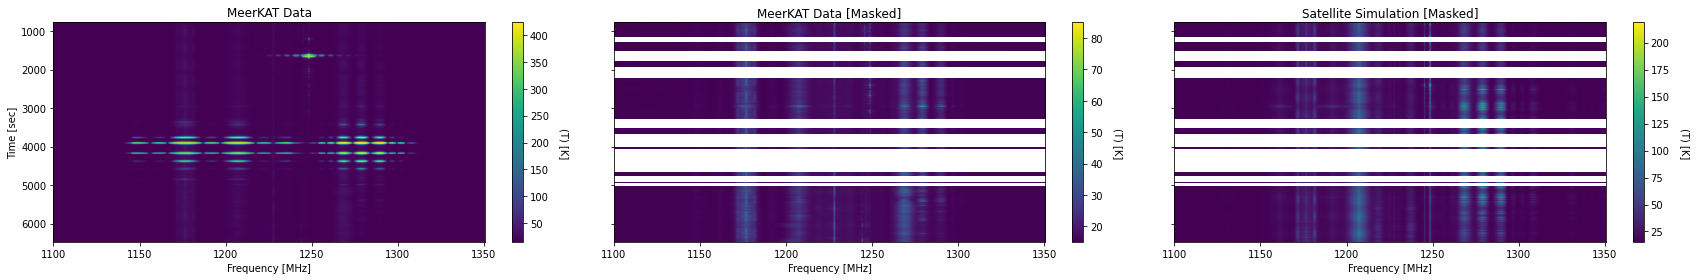

In [7]:
extent = [sat.frequency_band[sat.frequency_idx[0]], sat.frequency_band[sat.frequency_idx[1]],\
            sat.nd_s0[sat.time_idx[1]], sat.nd_s0[sat.time_idx[0]]]

masked_sim_sat = np.ma.array(data=sat.simulation_TOD_slice, mask=sat.mask_nearby_satellites_slice.T)
masked_data_sat = np.ma.array(data=sat.calibration_data_slice, mask=sat.mask_nearby_satellites_slice.T)


waterfall = [sat.calibration_data_slice, masked_data_sat, masked_sim_sat]
waterfall_name = ['MeerKAT Data', 'MeerKAT Data [Masked]', 'Satellite Simulation [Masked]' ]

fig, axs = plt.subplots(1, 3, figsize=(24,4), sharey=True)
fig.subplots_adjust()

for plot in range(3):
    ax=axs[plot]

    hb = ax.imshow(waterfall[plot].T, aspect='auto', extent=extent)
    ax.set_title(waterfall_name[plot])
    cbar = plt.colorbar(hb,ax=ax)
    cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)

    if plot==0:
        ax.set_ylabel('Time [sec]')
    ax.set_xlabel('Frequency [MHz]')

    
plt.tight_layout()
# plt.savefig('data_test_plots/'+fname+'/'+folder+'/waterfall_'+num+'.pdf')
plt.show()

In [8]:
# Chi2 
def chisq_func2(a_param):
    """
    Chi2 function which will take in all the parameters for the satellites
    """

    sat.excecute(a_param, obs_time_start=nd_s0[0], obs_time_end=nd_s0[-1], 
                 obs_frequency_start=1100, obs_frequency_end=1350, 
                 file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None], bandsize=None)


    # Masked
    simulation = np.ma.array(data=sat.simulation_TOD_slice, mask=sat.mask_nearby_satellites_slice.T)
    data = np.ma.array(data=sat.calibration_data_slice, mask=sat.mask_nearby_satellites_slice.T)

    sig = radiometer_eq(data=data)    

    chi_sq = np.ma.sum( (simulation - data )**2 / sig**2)
    print (chi_sq)
    return chi_sq

In [34]:
# Priors/Bounds
bnd_val = (0.0, 30)
bnds = [bnd_val for bnd_i in range(sat.alpha_len)]



In [36]:
# Optimization

print ('Running optimization')
signal_PL = opt.minimize(fun=chisq_func2, 
                         x0=dic, 
                         method='Powell',
                         bounds=bnds, 
                         tol=1e-6, 
                         options={'maxiter':20})

Running optimization
9700674465950.385
9737384464986.896
9793310148616.36
9714652803218.744
9705123404475.285
9700960223150.637
9699046627714.172
9698115826072.945
9697636763036.193
9697377432460.3
9697231193326.621
9697146173837.482
9697095676724.873
9697065249991.102
9697046744008.58
9697035420803.57
9697028466268.402
9697024184779.365
9697021545033.357
9697019916009.822
9697018910145.783
9697018288842.031
9697017904990.564
9697017667809.037
9697017521242.533
9697017430667.002
9697017374691.127
9697017340097.225
9697017318717.441
9697017305504.184
9697017297337.98
9697017292291.03
9697017289171.852
9697017287244.082
9697017286052.662
9697017285316.33
9697017284861.254
9697017284556.91
9829543814571.068
10181753382829.492
9719953397011.305
9691701708442.307
9691701708442.312
9691701708442.338
9691701708442.318
9691701708442.32
11509075033101.01
14947610439295.566
10211760424566.951
9726173914934.678
9546841841119.951
9482141192535.312
9459775103916.95
9450694781566.152
9450694781566.1

In [37]:
print ('Running 2nd init')
# 2nd initilization  
sat2 = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc=data_mkat,
            survey_info=[nd_s0, nd_s0_coords, frequency], 
            sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2_shuffle.csv',
            plots_loc='data_test_plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[1000,1500], 
            constellations=cons, nearby_satellites=nearby_constellation_path)

sat2.excecute(a_param=signal_PL.x, obs_time_start=nd_s0[0], obs_time_end=nd_s0[-1], 
              obs_frequency_start=1100, obs_frequency_end=1350, 
              file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None], bandsize=None)

Running 2nd init


In [38]:

# Storing the data
# print ('Storing data: '+num)
data_info = {'initial':dic,
             'time': sat.nd_s0[0:-1],
             'best-fit':signal_PL.x,
             'chi2_value':signal_PL.fun,
             'chi2_div':signal_PL.fun/sat2.simulation_TOD_slice.size
}

pickle.dump(data_info, open('data_test/'+str(fname)+'/data_info/parallel_'+folder+'/data_test_full_mask_full.p', 'wb'))



    

In [ ]:
data_info